In [31]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231116'
prefix_uptake = '20240326'
prefix_list = [prefix_default, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

# Read the data from `extract_ts_genvars.py`

Generate a growing season time series and an annual collection

In [32]:
collection_gs = {}
collection_annual = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    #filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    filt = (temp_data.index.month >= 1) & (temp_data.index.month <= 12)
    # Limit to < 2021 to be consistent with Paul's data
    filt = filt & (temp_data.index.year <= 2021)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data

/tmp/ipykernel_1000516/2078062346.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_1000516/2078062346.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


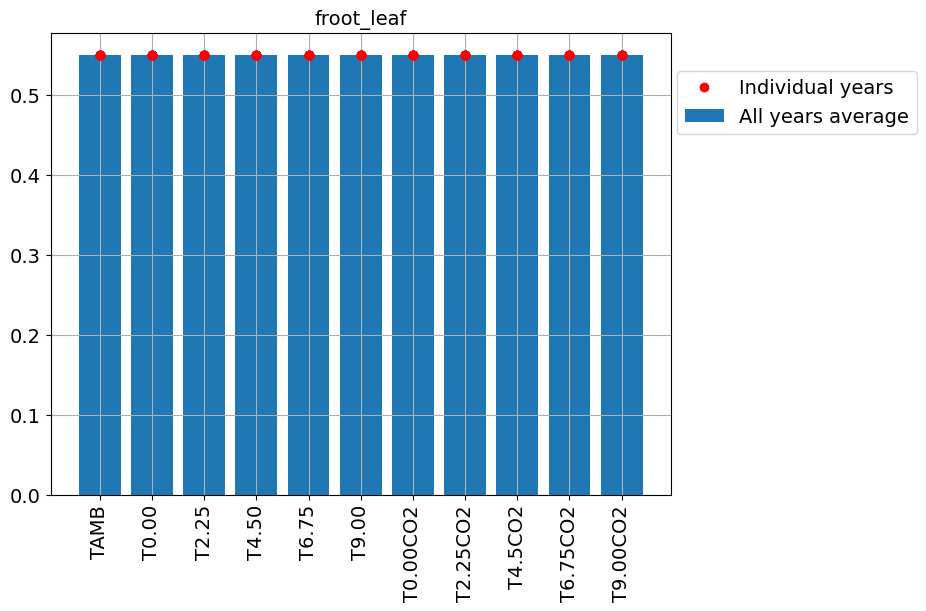

In [33]:
froot_leaf0 = 0.55
pft = '11'
fig, ax = plt.subplots(figsize = (8, 6))
temp = collection_gs[prefix].loc[:, (slice(None), 'ZWT_FROOT_PATCH', pft)
    ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
temp = temp * froot_leaf0
temp.columns = temp.columns.get_level_values(0)
plotID = np.broadcast_to(np.arange(temp.shape[1]).reshape(1, -1), temp.shape)
h, = ax.plot(plotID.reshape(-1), temp.values.reshape(-1), 'or')
h2 = ax.bar(plotID[0, :], np.mean(temp, axis = 0))
ax.set_xticks(np.arange(temp.shape[1]))
ax.set_xticklabels(xticklabels, rotation = 90)
ax.set_xlabel(None)
ax.set_title('froot_leaf')
ax.legend([h, h2], ['Individual years', 'All years average'], ncol = 1, loc = [1.01,0.78])
ax.grid(True)

In [34]:
"""
# Water limitation
# Skip

diff = collection_gs[prefix_uptake] - collection_gs[prefix_default]

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)
plot = '10'
zwt = diff.loc[:, (plot, 'ZWT', '0')]
tbot = diff.loc[:, (plot, 'TBOT', '0')]
for i, pft in enumerate(['2','3','11']):
    # BTRAN
    ax = axes[i, 0]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')
    ax.set_title('$\Delta$ BTRAN')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    if i == 0:
        ax.legend()

    # water table depth
    ax = axes[i, 1]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Water Table Depth (m)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)

    # soil moisture
    ax = axes[i, 2]
    cpool = collection_gs[prefix_default].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'r')
    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Soil water (m3 m-3)')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)"""

"\n# Water limitation\n# Skip\n\ndiff = collection_gs[prefix_uptake] - collection_gs[prefix_default]\n\nfig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)\nplot = '10'\nzwt = diff.loc[:, (plot, 'ZWT', '0')]\ntbot = diff.loc[:, (plot, 'TBOT', '0')]\nfor i, pft in enumerate(['2','3','11']):\n    # BTRAN\n    ax = axes[i, 0]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'BTRAN', pft)]\n    h = ax.plot(cpool.index, cpool, color = 'b', label = 'V1')\n    ax.set_title('$\\Delta$ BTRAN')\n    ax.grid(True)\n    plt.setp(ax.get_xticklabels(), rotation = 90)\n    if i == 0:\n        ax.legend()\n\n    # water table depth\n    ax = axes[i, 1]\n    cpool = collection_gs[prefix_default].loc[:, (plot, 'ZWT', '0')]\n    h = ax.plot(cpool.index, cpool, color = 'r')\n    cpool = collection_gs[prefix_uptake].loc[:, (plot, 'ZWT', '0')]\n   

In [35]:
"""# Column level surface water that affects moss inundation
# minimum difference
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

prefix = prefix_default
filt = (collection_gs[prefix].index.month >= 5) & (collection_gs[prefix].index.month <= 9)
temp = collection_gs[prefix].loc[filt, (slice(None), 'H2OSFC', '0')
    ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
temp.columns = temp.columns.get_level_values(0)
freq = (temp > 0).mean(axis = 0)
b1 = axes[0].bar(height = freq, x = np.arange(len(freq)) - 0.18, width = 0.35, facecolor = 'blue')
for i, col in enumerate(temp.columns):
    bp1 = axes[1].boxplot(temp[col].loc[temp[col] > 0], positions = [i-0.18], widths = 0.35, 
                     patch_artist = True, flierprops = {'markersize': 1})
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp1[element], color='b')
    for patch in bp1['boxes']:
        patch.set_facecolor('none')

prefix = prefix_uptake
filt = (collection_gs[prefix].index.month >= 5) & (collection_gs[prefix].index.month <= 9)
temp = collection_gs[prefix].loc[filt, (slice(None), 'H2OSFC', '0')
    ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
temp.columns = temp.columns.get_level_values(0)
freq = (temp > 0).mean(axis = 0)
b2 = axes[0].bar(height = freq, x = np.arange(len(freq)) + 0.18, width = 0.35, facecolor = 'r')
for i, col in enumerate(temp.columns):
    bp2 = axes[1].boxplot(temp[col].loc[temp[col] > 0], positions = [i+0.18], widths = 0.35, 
                     patch_artist = True, flierprops = {'markersize': 1})
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp2[element], color='r')
    for patch in bp2['boxes']:
        patch.set_facecolor('none')

axes[0].set_ylabel('Frequency of inundation')
axes[0].legend([b1, b2], ['ELM-default', 'ELM-nutrient'], frameon = False)
axes[1].set_ylabel('Surface Water Depth (mm)')

axes[0].set_xticks(np.arange(len(freq)))
axes[0].set_xticklabels(xticklabels, rotation = 90)
axes[0].set_xlabel(None)
axes[1].set_xticks(np.arange(len(freq)))
axes[1].set_xticklabels(xticklabels, rotation = 90)
axes[1].set_xlabel(None)
axes[1].set_yscale('log')"""

"# Column level surface water that affects moss inundation\n# minimum difference\nfig, axes = plt.subplots(1, 2, figsize = (15, 5))\n\nprefix = prefix_default\nfilt = (collection_gs[prefix].index.month >= 5) & (collection_gs[prefix].index.month <= 9)\ntemp = collection_gs[prefix].loc[filt, (slice(None), 'H2OSFC', '0')\n    ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]\ntemp.columns = temp.columns.get_level_values(0)\nfreq = (temp > 0).mean(axis = 0)\nb1 = axes[0].bar(height = freq, x = np.arange(len(freq)) - 0.18, width = 0.35, facecolor = 'blue')\nfor i, col in enumerate(temp.columns):\n    bp1 = axes[1].boxplot(temp[col].loc[temp[col] > 0], positions = [i-0.18], widths = 0.35, \n                     patch_artist = True, flierprops = {'markersize': 1})\n    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:\n        plt.setp(bp1[element], color='b')\n    for patch in bp1['boxes']:\n        patch.set_facecolor('none')\n\nprefix = prefix_uptake\nf

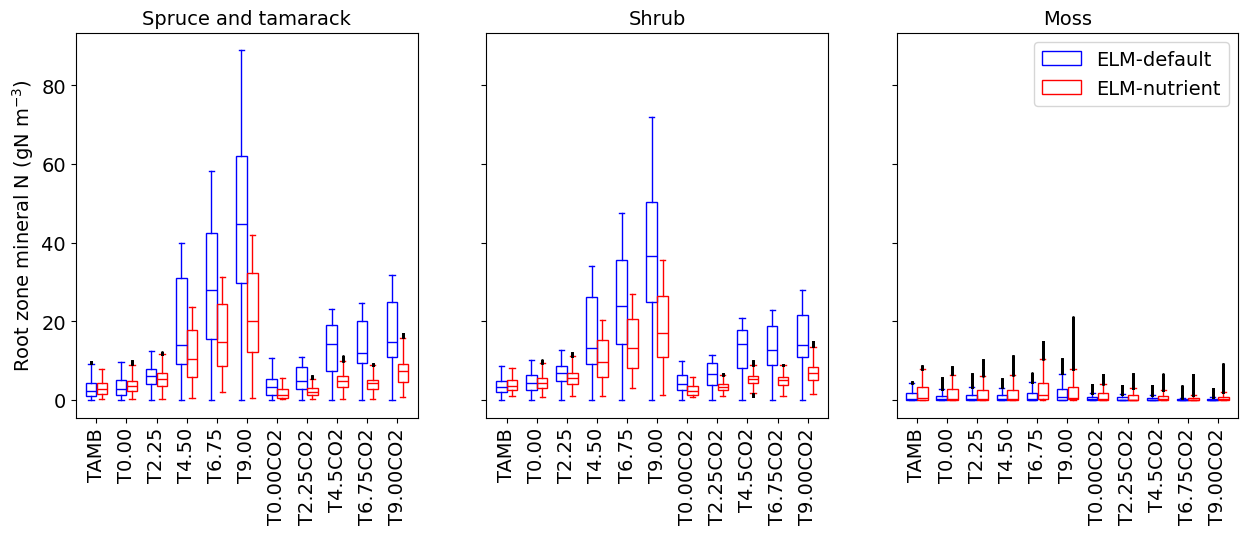

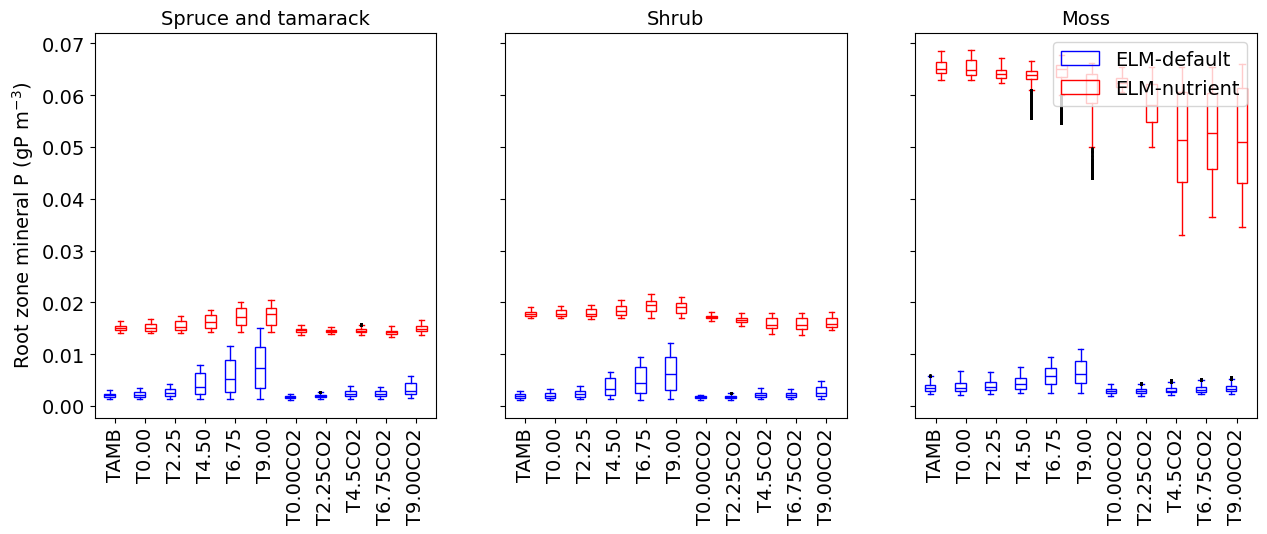

In [36]:
# Column nutrient level
for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','11','12'],['Spruce','Shrub','Moss'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp1 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) - 0.18, widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1})

        prefix = prefix_uptake
        temp = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)
            ].loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
        temp.columns = temp.columns.get_level_values(0)
        bp2 = ax.boxplot(temp, positions = np.arange(temp.shape[1]) + 0.18, widths = 0.35, 
                         patch_artist = True, flierprops = {'markersize': 1})

        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp1[element], color='b')
            plt.setp(bp2[element], color='r')
        for patch in bp1['boxes']:
            patch.set_facecolor('none')
        for patch in bp2['boxes']:
            patch.set_facecolor('none')

        if i == 0:
            ax.set_ylabel(f'Root zone mineral {nu} (g{nu}' + ' m$^{-3}$)')
        if i == 2:
            ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ELM-default', 'ELM-nutrient'], 
                      loc='upper right')

        #if nu == 'N':
        #    ax.set_ylim([0, 20])
        #else:
        #    ax.set_ylim([0, 0.006])

        ax.set_xticks(np.arange(temp.shape[1]))
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.set_xlabel(None)
        if pft == '2':
            ax.set_title('Spruce and tamarack')
        else:
            ax.set_title(name)

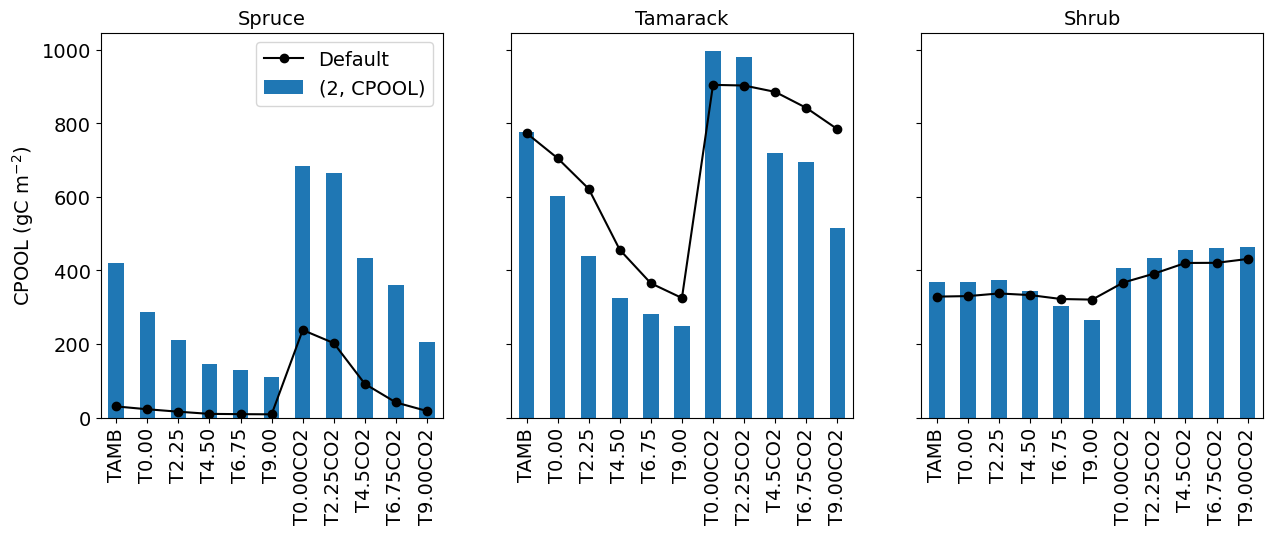

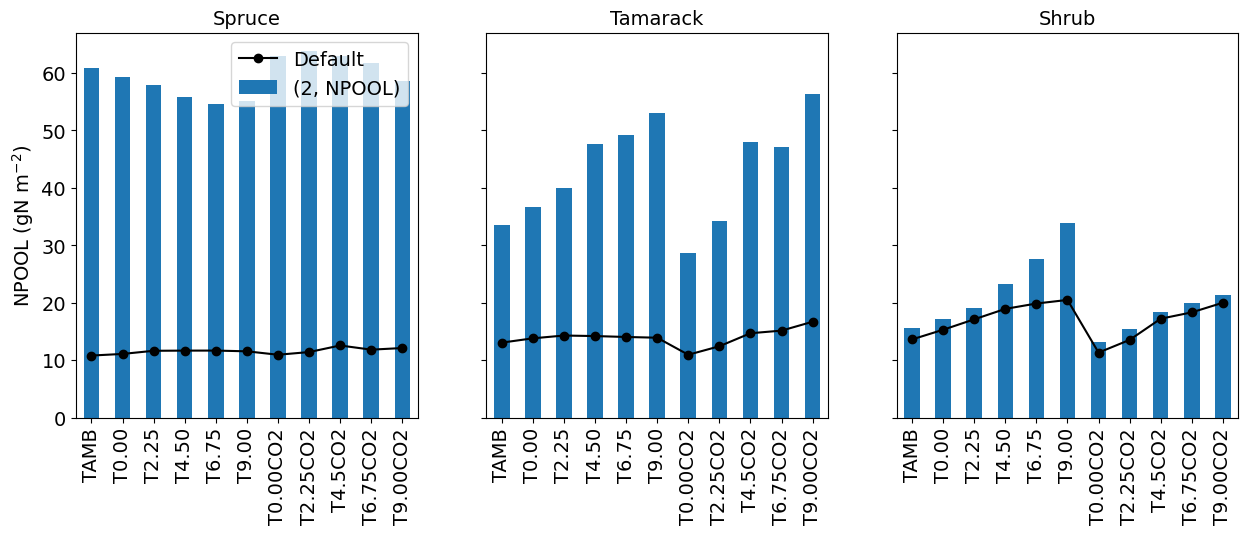

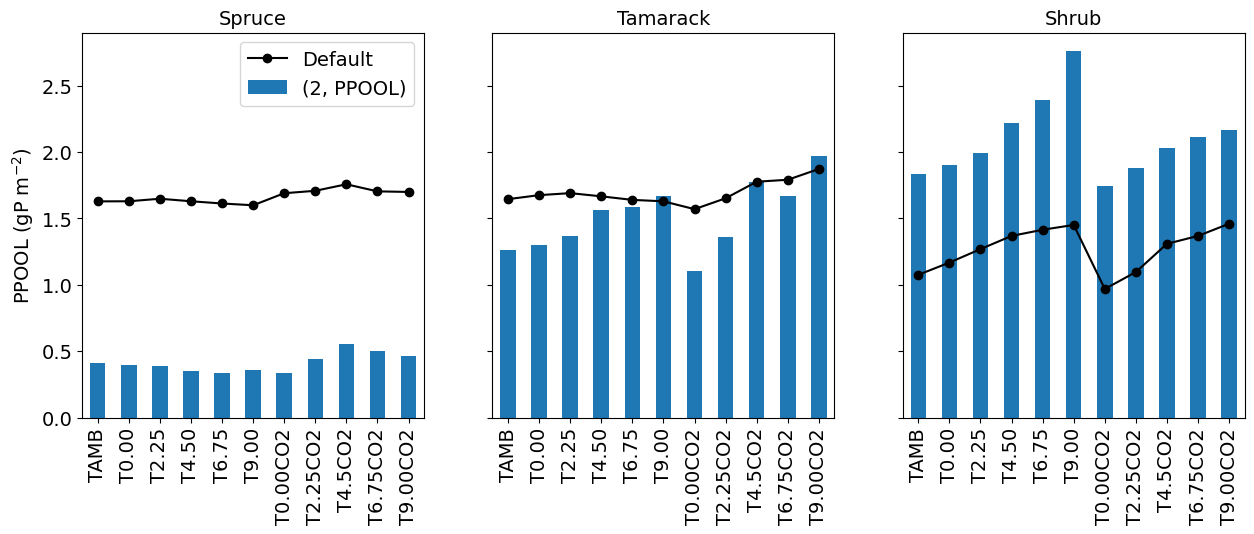

In [37]:
# CPOOL & NPOOL & PPOOL sizes
for nu in ['C','N','P']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        prefix = prefix_default
        temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        xpool = temp.loc[:, (pft, f'{nu}POOL')]
        ax.plot(range(len(xpool)), xpool, '-ko', label = 'Default')

        prefix = prefix_uptake
        temp2 = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        xpool2 = temp2.loc[:, (pft, f'{nu}POOL')]

        #print(nu, pft, name)
        #print(retemp)

        if i == 0:
            xpool2.plot(kind='bar', stacked=True, ax = ax)
        else:
            xpool2.plot(kind='bar', stacked=True, ax = ax, legend = False)

        if i == 0:
            ax.set_ylabel(f'{nu}POOL (g{nu}' + ' m$^{-2}$)')
            ax.legend()

        ax.set_xticklabels(xticklabels)
        ax.set_xlabel(None)
        ax.set_title(name)

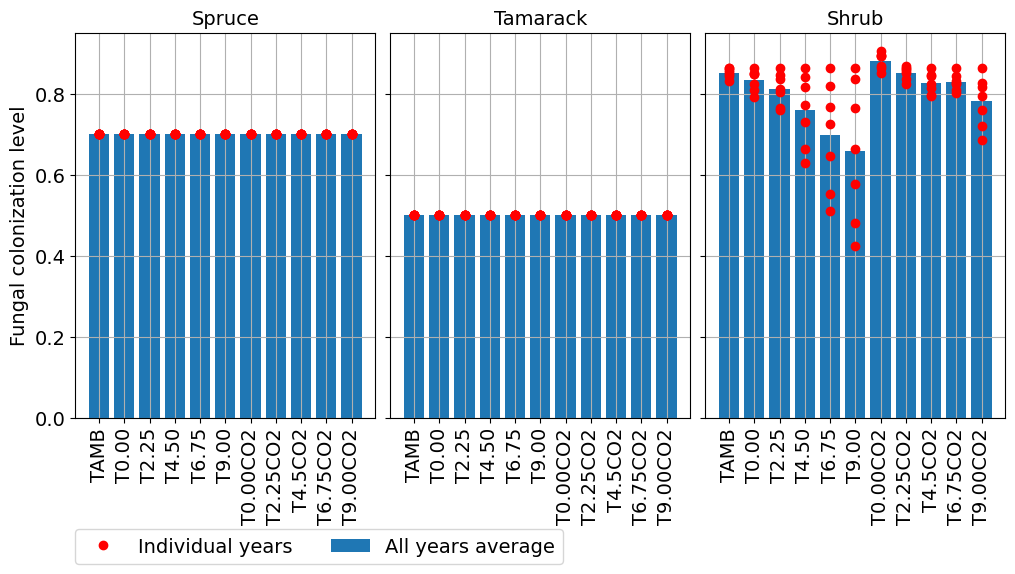

In [38]:
# Fungi inhibition on nutrient uptake
prefix = prefix_uptake

fig, axes = plt.subplots(1, 3, figsize = (12, 5), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]

    temp = collection_gs[prefix].loc[:, (slice(None), 'FUNGI_INHIB_PATCH', pft)
        ].resample('1Y').mean().loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]
    temp.columns = temp.columns.get_level_values(0)
    plotID = np.broadcast_to(np.arange(temp.shape[1]).reshape(1, -1), temp.shape)
    h, = ax.plot(plotID.reshape(-1), temp.values.reshape(-1), 'or')
    h2 = ax.bar(plotID[0, :], np.mean(temp, axis = 0))

    if i == 0:
        ax.set_ylabel('Fungal colonization level')
        ax.legend([h, h2], ['Individual years', 'All years average'], ncol = 2, loc = [0, -0.38])

    ax.set_xticks(np.arange(temp.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    #if i == 0:
    #    ax.set_title('Spruce and Tamarack')
    #else:
    ax.set_title(name)
    ax.grid(True)

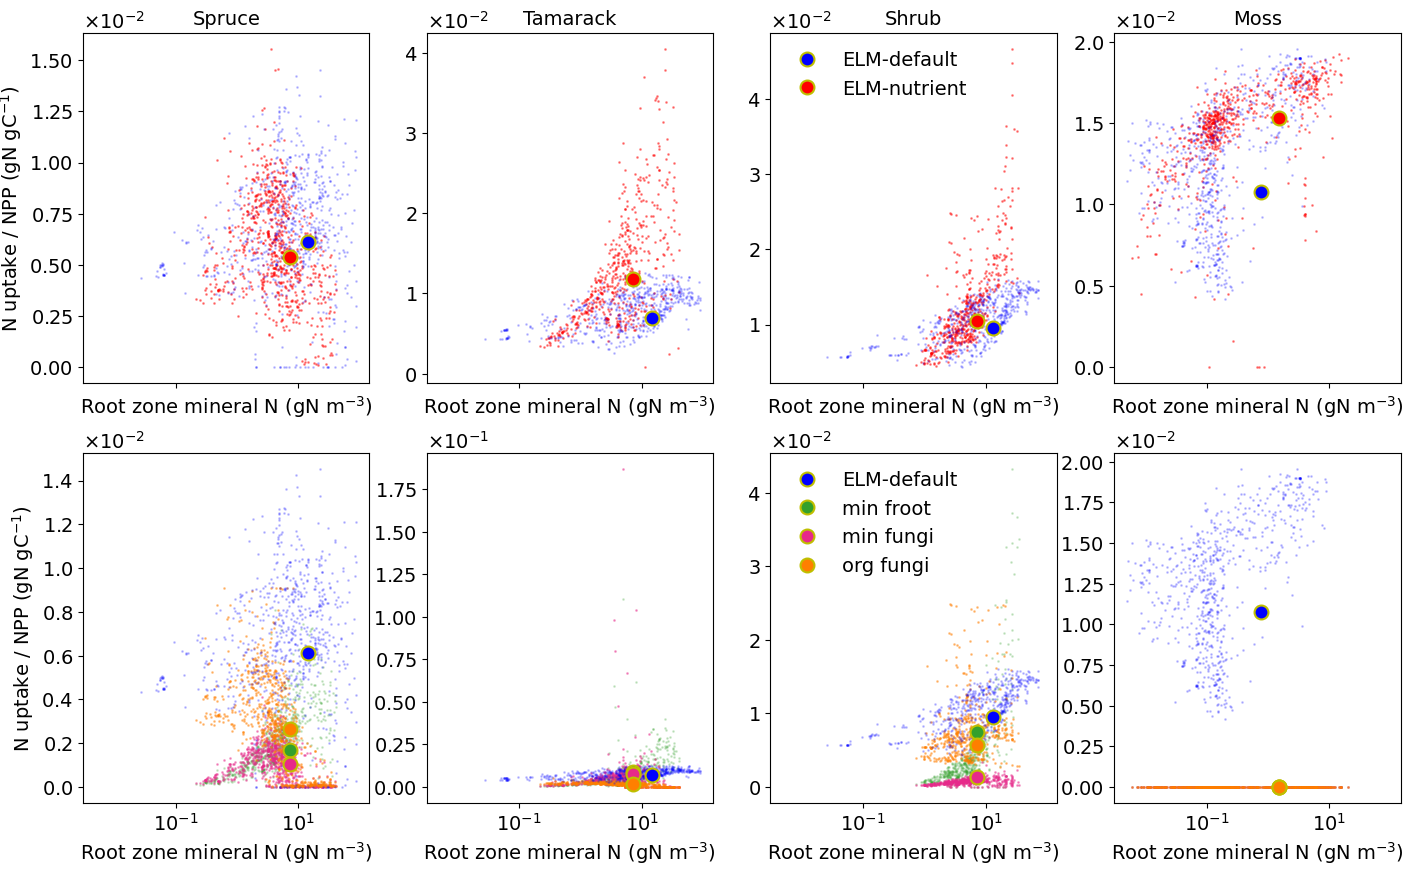

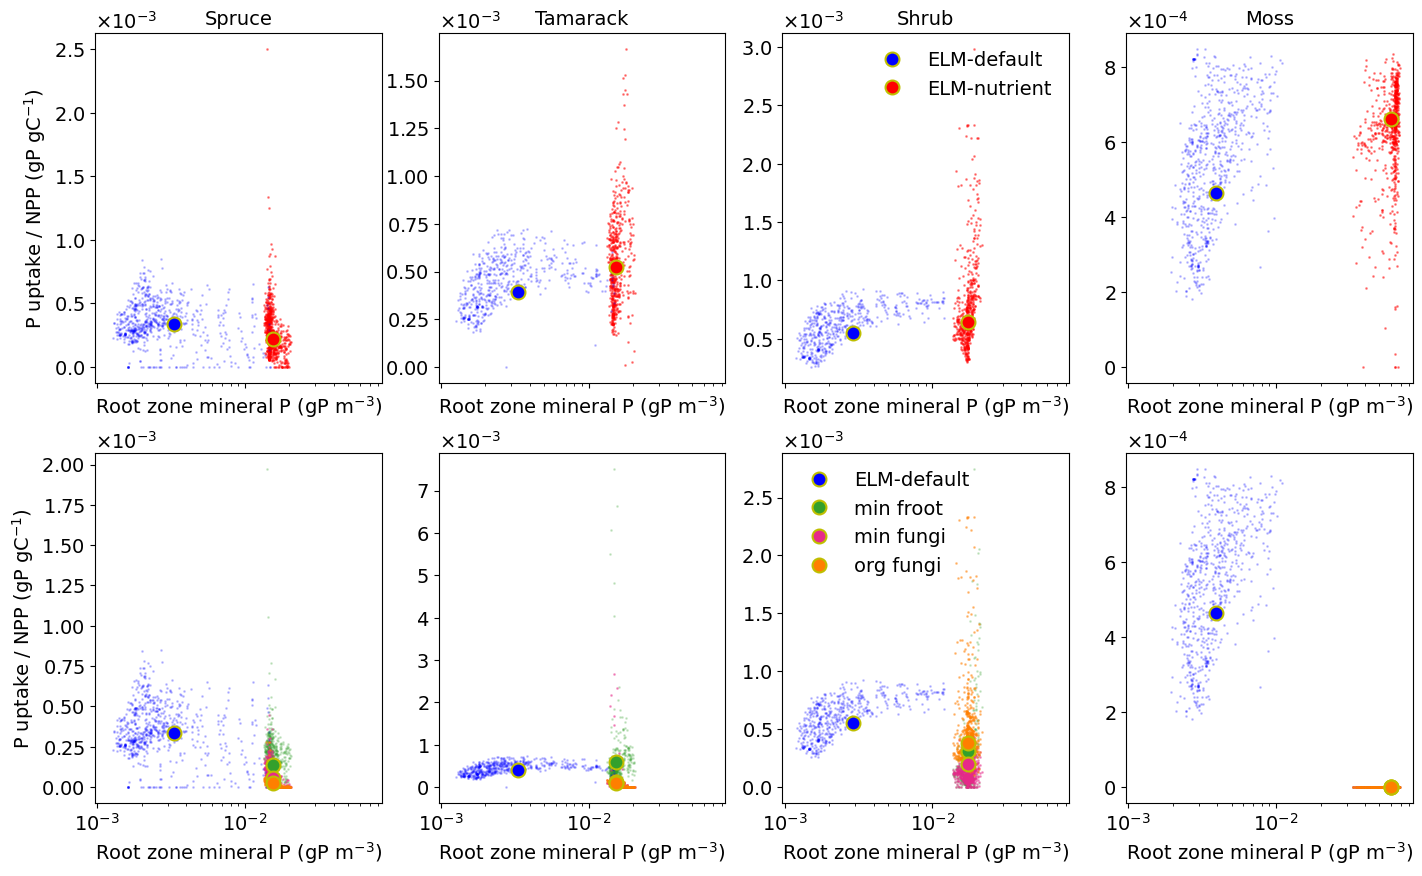

In [39]:
# Mineral + organic nutrient uptake # Do not divided by C assimilation
plot = chambers_ordered['amb'][-1]

for nu in ['N','P']:
    if nu == 'N':
        nu_var = 'SMINN_vr_ROOTFR'
    else:
        nu_var = 'SOLUTIONP_vr_ROOTFR'

    fig, axes = plt.subplots(2, 4, figsize = (17, 10), sharex = True, sharey = False)
    for i, (pft,name) in enumerate(zip(['2','3','11','12'],['Spruce','Tamarack','Shrub','Moss'])):
        for j in range(2):
            ax = axes[j, i]
            for prefix, pname, colr in zip(prefix_list, ['ELM-default', 'ELM-nutrient'], ['b','r']):
                sminn = collection_gs[prefix].loc[:, (slice(None), nu_var, pft)]
                sminn = sminn.resample('1M').mean()
                sminn_mean = sminn.mean().mean()

                # C assimilation
                cdemand = collection_gs[prefix].loc[:, (slice(None), 'AVAILC', pft)]

                smin_uptake = collection_gs[prefix].loc[:, (slice(None), 
                                                            f'SMIN{nu}_TO_{nu}POOL', pft)]
                min_cpool = smin_uptake.resample('1M').mean() / cdemand.resample('1M').mean().values
                min_cpool_mean = smin_uptake.mean().mean() / cdemand.mean().mean()

                if pname == 'ELM-nutrient':
                    min_uptake_root = collection_gs[prefix].loc[:, (slice(None), 
                        f'FROOT_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_uptake_fungi = collection_gs[prefix].loc[:, (slice(None), 
                        f'FUNGI_{nu}DEMAND_POT', pft)] / collection_gs[prefix].loc[:, 
                        (slice(None), f'PLANT_{nu}DEMAND_POT', pft)].values * smin_uptake.values
                    min_cpool_root = min_uptake_root.resample('1M').mean() / \
                                     cdemand.resample('1M').mean().values
                    min_cpool_fungi = min_uptake_fungi.resample('1M').mean() / \
                                      cdemand.resample('1M').mean().values
                    min_cpool_root_mean = min_uptake_root.mean().mean() / cdemand.mean().mean()
                    min_cpool_fungi_mean = min_uptake_fungi.mean().mean() / cdemand.mean().mean()

                    sorg_uptake = collection_gs[prefix].loc[:, \
                        (slice(None), f'FUNGI_SOM_TO_{nu}POOL', pft)]
                    org_cpool = sorg_uptake.resample('1M').mean() / \
                        cdemand.resample('1M').mean().values
                    org_cpool_mean = sorg_uptake.mean().mean() / cdemand.mean().mean()

                if pname == 'ELM-default':
                    h = ax.plot(sminn.values.reshape(-1), min_cpool.values.reshape(-1), 'o',
                                color = colr, markersize = 1, alpha = 0.2)
                    ax.plot(sminn_mean, min_cpool_mean, 'o',
                            color = colr, markersize = 10, markeredgecolor = 'y',
                            markeredgewidth = 1.5, label = pname)
                else:
                    if j == 0:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool.values + min_cpool).values.reshape(-1), 'o',
                                    color = colr, markersize = 1, alpha = 0.4, 
                                    zorder = 1)
                        ax.plot(sminn_mean, min_cpool_mean + org_cpool_mean, 'o',
                                color = colr, markersize = 10, markeredgecolor = 'y', 
                                zorder = 3, markeredgewidth = 1.5, label = pname)
                    else:
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_root).values.reshape(-1), 'o',
                                    color = '#33a02c', markersize = 1,
                                    alpha = 0.2, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_root_mean, 'o',
                                color = '#33a02c', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'min froot')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (min_cpool_fungi).values.reshape(-1), 'o',
                                    color = '#e7298a', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, min_cpool_fungi_mean, 'o',
                                color = '#e7298a', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5, label = f'min fungi')
                        h = ax.plot(sminn.values.reshape(-1), 
                                    (org_cpool).values.reshape(-1), 'o',
                                    color = '#ff7f00', markersize = 1,
                                    alpha = 0.4, zorder = 1)
                        ax.plot(sminn_mean, org_cpool_mean, 'o', label = f'org fungi', 
                                color = '#ff7f00', markersize = 10, markeredgecolor = 'y',
                                zorder = 3, markeredgewidth = 1.5)

            if i == 0:
                if nu == 'N':
                    ax.set_ylabel(f'{nu} uptake / NPP (g' + nu + ' gC$^{-1}$)')
                else:
                    ax.set_ylabel(f'{nu} uptake / NPP (g' + nu + ' gC$^{-1}$)')

            if i == 2:
                ax.legend(frameon = False)

            if j == 0:
                ax.set_title(name)

            if nu == 'N':
                ax.set_xlabel(f'Root zone mineral {nu} (g{nu} ' + 'm$^{-3}$)')
            else:
                ax.set_xlabel(f'Root zone mineral {nu} (g' + f'{nu} ' + 'm$^{-3}$)')
            ax.set_xscale('log')
            #ax.set_yscale('log')
            ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

In [40]:
LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                    0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                    7.829766, 12.92532, 21.32647, 35.17762])

def get_vertical_c(plot, nu):
    # gather vertical soil organic C distribution
    LEVGRND_I = np.append(np.insert((LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
                                    ), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
    THICKNESS = np.diff(LEVGRND_I)

    soc = pd.DataFrame(0, index = range(len(LEVGRND)), 
                       columns = pd.MultiIndex.from_product(
                        [[prefix_default, prefix_uptake], ['Litter C', 'Soil C']]))

    for prefix in [prefix_default, prefix_uptake]:
        hr = xr.open_mfdataset([os.path.join(
            os.environ['E3SM_ROOT'], 'output', f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', 
            'spruce_treatments', f'plot{int(plot):02d}_US-SPR_ICB20TRCNPRDCTCBC', 'run', 
            f'plot{int(plot):02d}_US-SPR_ICB20TRCNPRDCTCBC.elm.h1.{year}-01-01-00000.nc'
            ) for year in range(2015, 2022)])
        for var in [f'LITR1{nu}_vr', f'LITR2{nu}_vr', f'LITR3{nu}_vr']:
            soc.loc[:, (prefix, f'Litter {nu}')] = hr[var].mean(axis = 0)[:, 0] * 0.64 + \
                                    hr[var].mean(axis = 0)[:, 0] * 0.36
        for var in [f'SOIL1C_vr', f'SOIL2C_vr', f'SOIL3C_vr', f'SOIL4C_vr']:
            soc.loc[:, (prefix, f'Soil {nu}')] = hr[var].mean(axis = 0)[:, 0] * 0.64 + \
                                    hr[var].mean(axis = 0)[:, 0] * 0.36
            if var in ['SOIL1C_vr', 'SOI2C_vr']:
                soc.loc[:, (prefix, f'Soil {nu}')] = \
                    soc.loc[:, (prefix, f'Soil {nu}')].values / 22
            else:
                soc.loc[:, (prefix, f'Soil {nu}')] = \
                    soc.loc[:, (prefix, f'Soil {nu}')].values / 20

        hr.close()

    soc = soc * THICKNESS.reshape(-1, 1)
    return soc

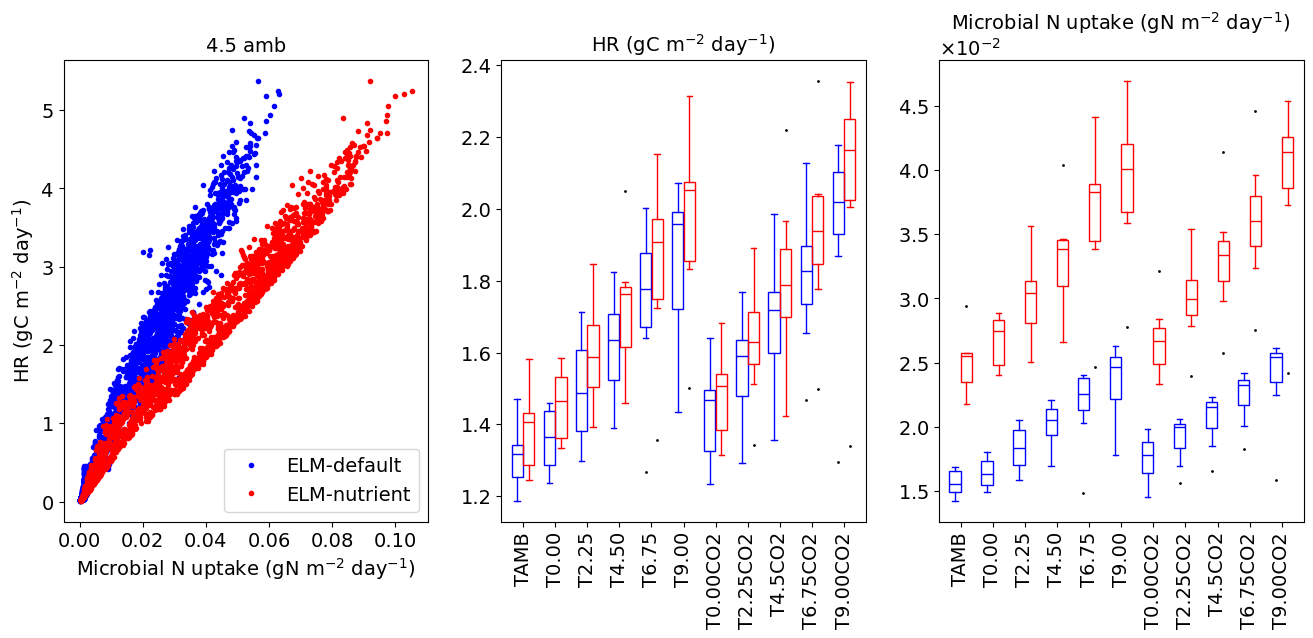

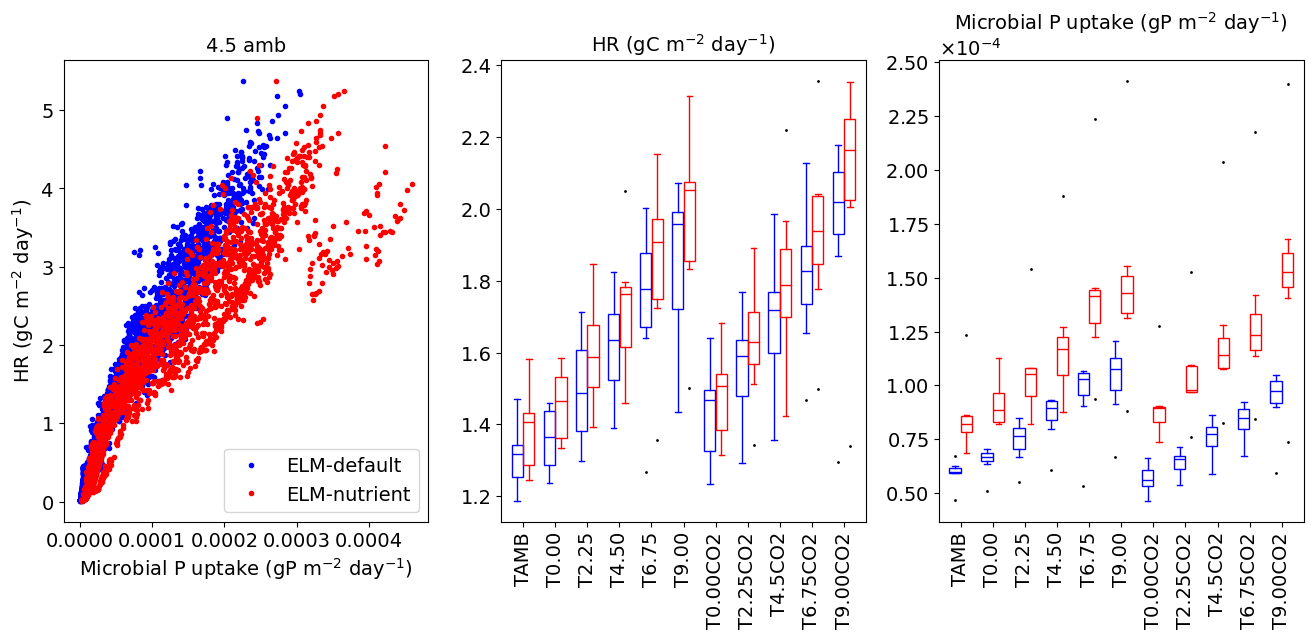

In [41]:
for varname, varname2, nu in zip(
    ['ACTUAL_IMMOB', 'ACTUAL_IMMOB_P'],
    ['FPI', 'FPI_P'], ['N', 'P']
):

    fig, axes = plt.subplots(1, 3, figsize = (16, 6))

    ###########################
    # N requirement per unit HR
    ###########################
    ax = axes.flat[0]
    plot = chambers_ordered['amb'][2]

    x1 = collection_gs[prefix_default].loc[:, (plot, varname, '0')] * 86400
    y1 = collection_gs[prefix_default].loc[:, (plot, 'HR', '0')] * 86400

    x2 = collection_gs[prefix_uptake].loc[:, (plot, varname, '0')] * 86400
    y2 = collection_gs[prefix_uptake].loc[:, (plot, 'HR', '0')] * 86400

    ax.plot(x1, y2, '.b')
    ax.plot(x2, y2, '.r')
    ax.set_xlabel(f'Microbial {nu} uptake (g{nu} ' + 'm$^{-2}$ day$^{-1}$)')
    ax.set_ylabel('HR (gC m$^{-2}$ day$^{-1}$)')
    ax.legend(['ELM-default', 'ELM-nutrient'])
    ax.set_title(f'4.5 amb')

    ###########################
    # Actual simulated HR
    ###########################
    ax = axes.flat[1]
    val = pd.DataFrame(np.nan, 
        index = chambers_ordered['amb'] + chambers_ordered['elev'], 
        columns = pd.MultiIndex.from_product(
            [[prefix_default, prefix_uptake], range(2015, 2022)])
    )

    for c in chambers_ordered['amb'] + chambers_ordered['elev']:
        for prefix in [prefix_default, prefix_uptake]:
            val.loc[c, prefix] = collection_gs[prefix].loc[:, (c,'HR','0')
                                                           ].resample('1Y').mean().values
    val = val * 86400

    bp1 = ax.boxplot(val.loc[:, prefix_default].T, 
                        positions = np.arange(1, len(xticklabels)+1) - 0.18, widths = 0.35,
                        patch_artist = True, flierprops = {'markersize': 1})
    bp2 = ax.boxplot(val.loc[:, prefix_uptake].T, 
                        positions = np.arange(1, len(xticklabels)+1) + 0.18, widths = 0.35,
                        patch_artist = True, flierprops = {'markersize': 1})

    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp1[element], color='b')
        plt.setp(bp2[element], color='r')
    for patch in bp1['boxes']:
        patch.set_facecolor('none')
    for patch in bp2['boxes']:
        patch.set_facecolor('none')

    #ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ELM-default', 'ELM-nutrient'], 
    #        loc='upper left')
    ax.set_title('HR (gC m$^{-2}$ day$^{-1}$)')
    ax.set_xticks(np.arange(1, len(xticklabels)+1))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)

   
    ###########################
    # Actual simulated Immobilization
    ###########################
    ax = axes.flat[2]
    val = pd.DataFrame(np.nan, 
        index = chambers_ordered['amb'] + chambers_ordered['elev'], 
        columns = pd.MultiIndex.from_product(
            [[prefix_default, prefix_uptake], range(2015, 2022)])
    )

    for c in chambers_ordered['amb'] + chambers_ordered['elev']:
        for prefix in [prefix_default, prefix_uptake]:
            val.loc[c, prefix] = collection_gs[prefix].loc[:, (c,varname,'0')
                                                           ].resample('1Y').mean().values
    val = val * 86400

    bp1 = ax.boxplot(val.loc[:, prefix_default].T, 
                     positions = np.arange(1, len(xticklabels)+1) - 0.18, widths = 0.35,
                     patch_artist = True, flierprops = {'markersize': 1})
    bp2 = ax.boxplot(val.loc[:, prefix_uptake].T, 
                        positions = np.arange(1, len(xticklabels)+1) + 0.18, widths = 0.35,
                        patch_artist = True, flierprops = {'markersize': 1})

    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp1[element], color='b')
        plt.setp(bp2[element], color='r')
    for patch in bp1['boxes']:
        patch.set_facecolor('none')
    for patch in bp2['boxes']:
        patch.set_facecolor('none')

    #ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ELM-default', 'ELM-nutrient'], 
    #        loc='upper left')
    ax.set_title(f'Microbial {nu} uptake (g{nu} ' + 'm$^{-2}$ day$^{-1}$)')
    ax.set_xticks(np.arange(1, len(xticklabels)+1))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    """ ###########################
    # Vertical distribution of soil organic matter
    ###########################
    ax = axes.flat[2]
    plot = chambers_ordered['amb'][2]
    soc = get_vertical_c(plot, nu)

    ax.plot(soc.loc[:9, (prefix_default, f'Litter {nu}')],
            LEVGRND[:10], '-ob')
    ax.plot(soc.loc[:9, (prefix_default, f'Soil {nu}')],
            LEVGRND[:10], ':ob')
    ax.plot(soc.loc[:9, (prefix_uptake, f'Litter {nu}')],
            LEVGRND[:10], '-or')
    ax.plot(soc.loc[:9, (prefix_uptake, f'Soil {nu}')],
            LEVGRND[:10], ':or')
    ax.legend(['Litter', 'Soil'])
    ax.invert_yaxis()
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=False)
    ax.set_xlabel(f'g{nu} m$^{-2}$')
    ax.set_ylabel('Depth (m)') """

In [42]:
""" # Seasonality in CPOOL/(FROOTC + LEAFC), and CPOOL
# Because the situation is similar acorss chambers, choose a medium chamber, 
# 4.5 degC CO2
cmap = get_cmap('viridis_r')
clist_amb = [cmap((i+0.5)/5) for i in range(5)]
cmap = get_cmap('magma_r')
clist_elev = [cmap((i+0.5)/5) for i in range(5)]
plot = chambers_ordered['amb'][2]


fig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = False)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):

    ax = axes[0, i]
    for prefix in [prefix_default, prefix_uptake]:
        temp = collection_gs[prefix].loc[:, (slice(None), f'CPOOL', pft)
                ].values.reshape(-1, 365, 11).mean(axis = 0)
        temp = pd.DataFrame(temp, index = range(1, 366), 
                            columns = collection_gs[prefix].columns.levels[0])
        # for j,c in enumerate(chambers_ordered['amb']):
        ax.plot(range(1, 366), temp.loc[:, plot], '-o')
        #for j,c in enumerate(chambers_ordered['elev']):
        #    ax.plot(range(1, 366), temp.loc[:, c], '-o', color = clist_elev[j])
    if i == 0:
        ax.set_ylabel(f'CPOOL (gC m$^{-2}$)')
        ax.legend(['ELM-default', 'ELM-nutrient'])

    ax = axes[1, i]
    for prefix in [prefix_default, prefix_uptake]:
        temp = (collection_gs[prefix].loc[:, (slice(None), f'CPOOL', pft)].values \
                / (collection_gs[prefix].loc[:, (slice(None), f'FROOTC', pft)].values + \
                collection_gs[prefix].loc[:, (slice(None), f'LEAFC', pft)].values) \
        ).reshape(-1, 365, 11).mean(axis = 0)
        temp = pd.DataFrame(temp, index = range(1, 366), 
                            columns = collection_gs[prefix].columns.levels[0])
        temp = temp[temp < 20]

        #for j,c in enumerate(chambers_ordered['amb']):
        ax.plot(range(1, 366), temp.loc[:, plot], '-o')
        #for j,c in enumerate(chambers_ordered['elev']):
        #    ax.plot(range(1, 366), temp.loc[:, plot], '-o', color = clist_elev[j])

    if i == 0:
        ax.set_ylabel(f'CPOOL/(FROOTC+LEAFC)')
        #ax.legend()

    ax.set_xticklabels(range(1,366))
    ax.set_xlabel('Month')
    ax.set_title(name) """

" # Seasonality in CPOOL/(FROOTC + LEAFC), and CPOOL\n# Because the situation is similar acorss chambers, choose a medium chamber, \n# 4.5 degC CO2\ncmap = get_cmap('viridis_r')\nclist_amb = [cmap((i+0.5)/5) for i in range(5)]\ncmap = get_cmap('magma_r')\nclist_elev = [cmap((i+0.5)/5) for i in range(5)]\nplot = chambers_ordered['amb'][2]\n\n\nfig, axes = plt.subplots(2, 3, figsize = (15, 10), sharex = True, sharey = False)\nfor i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):\n\n    ax = axes[0, i]\n    for prefix in [prefix_default, prefix_uptake]:\n        temp = collection_gs[prefix].loc[:, (slice(None), f'CPOOL', pft)\n                ].values.reshape(-1, 365, 11).mean(axis = 0)\n        temp = pd.DataFrame(temp, index = range(1, 366), \n                            columns = collection_gs[prefix].columns.levels[0])\n        # for j,c in enumerate(chambers_ordered['amb']):\n        ax.plot(range(1, 366), temp.loc[:, plot], '-o')\n        #for j,c in enu

/tmp/ipykernel_1000516/3665943391.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('viridis_r')
/tmp/ipykernel_1000516/3665943391.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('magma_r')


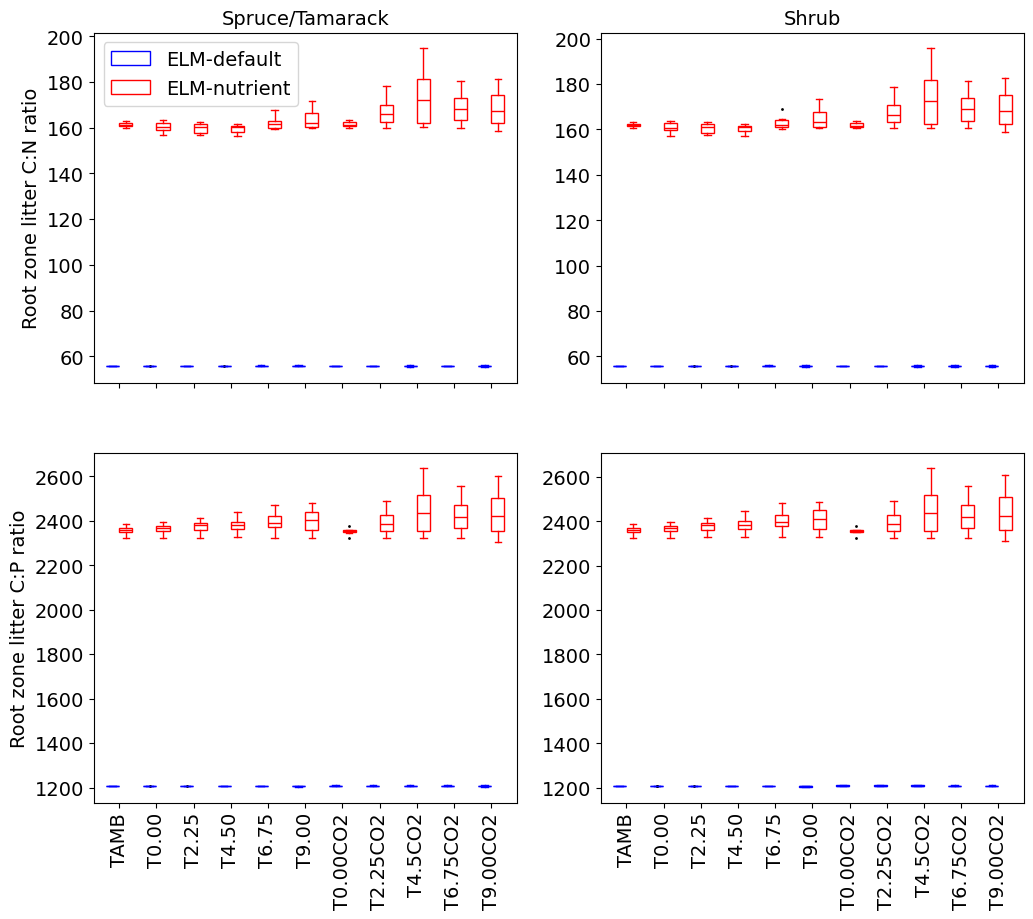

In [43]:
# Only need to do the 30cm because of HR!
cmap = get_cmap('viridis_r')
clist_amb = [cmap((i+0.5)/5) for i in range(5)]
cmap = get_cmap('magma_r')
clist_elev = [cmap((i+0.5)/5) for i in range(5)]

fig, axes = plt.subplots(2, 2, figsize = (12, 10), sharex = True, sharey = False)

for k, nu in enumerate(['N', 'P']):

    # Tamarack is the same as Spruce
    for i, (pft,name) in enumerate(zip(['2','11'],['Spruce','Shrub'])):

        litter_nu = pd.DataFrame(np.nan, 
            index = chambers_ordered['amb'] + chambers_ordered['elev'], 
            columns = pd.MultiIndex.from_product(
                [[prefix_default, prefix_uptake], range(2015, 2022)])
        )
        litter_c = pd.DataFrame(np.nan, 
            index = chambers_ordered['amb'] + chambers_ordered['elev'], 
            columns = pd.MultiIndex.from_product(
                [[prefix_default, prefix_uptake], range(2015, 2022)])
        )

        # Sum up the three litter pools, LITR1, LITR2, LITR3
        for c in chambers_ordered['amb'] + chambers_ordered['elev']:
            for prefix in [prefix_default, prefix_uptake]:
                litter_nu.loc[c, prefix] = ( \
                    collection_gs[prefix].loc[:, (c,f'LITR1{nu}_vr_ROOTFR',pft)] + 
                    collection_gs[prefix].loc[:, (c, f'LITR2{nu}_vr_ROOTFR',pft)].values + 
                    collection_gs[prefix].loc[:, (c,f'LITR3{nu}_vr_ROOTFR',pft)].values
                    ).resample('1Y').mean().values

                litter_c.loc[c, prefix] = ( \
                    collection_gs[prefix].loc[:, (c,f'LITR1C_vr_ROOTFR',pft)] + 
                    collection_gs[prefix].loc[:, (c, f'LITR2C_vr_ROOTFR',pft)].values + 
                    collection_gs[prefix].loc[:, (c,f'LITR3C_vr_ROOTFR',pft)].values
                    ).resample('1Y').mean().values
        
        # C:N ratio
        litter_ratio = litter_c / litter_nu

        ax = axes[k, i]

        bp1 = ax.boxplot(litter_ratio.loc[:, prefix_default].T, 
                         positions = np.arange(1, len(xticklabels)+1) - 0.18, widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1})
        bp2 = ax.boxplot(litter_ratio.loc[:, prefix_uptake].T, 
                         positions = np.arange(1, len(xticklabels)+1) + 0.18, widths = 0.35,
                         patch_artist = True, flierprops = {'markersize': 1})

        for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
            plt.setp(bp1[element], color='b')
            plt.setp(bp2[element], color='r')
        for patch in bp1['boxes']:
            patch.set_facecolor('none')
        for patch in bp2['boxes']:
            patch.set_facecolor('none')

        if i == 0:
            if nu == 'N':
                ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ELM-default', 'ELM-nutrient'], 
                        loc='upper left')
            ax.set_ylabel(f'Root zone litter C:{nu} ratio')
        if k == 0:
            if i == 0:
                ax.set_title('Spruce/Tamarack')
            else:
                ax.set_title(name)

        ax.set_xticks(np.arange(1, len(xticklabels)+1))
        ax.set_xticklabels(xticklabels, rotation = 90)
        ax.set_xlabel(None)

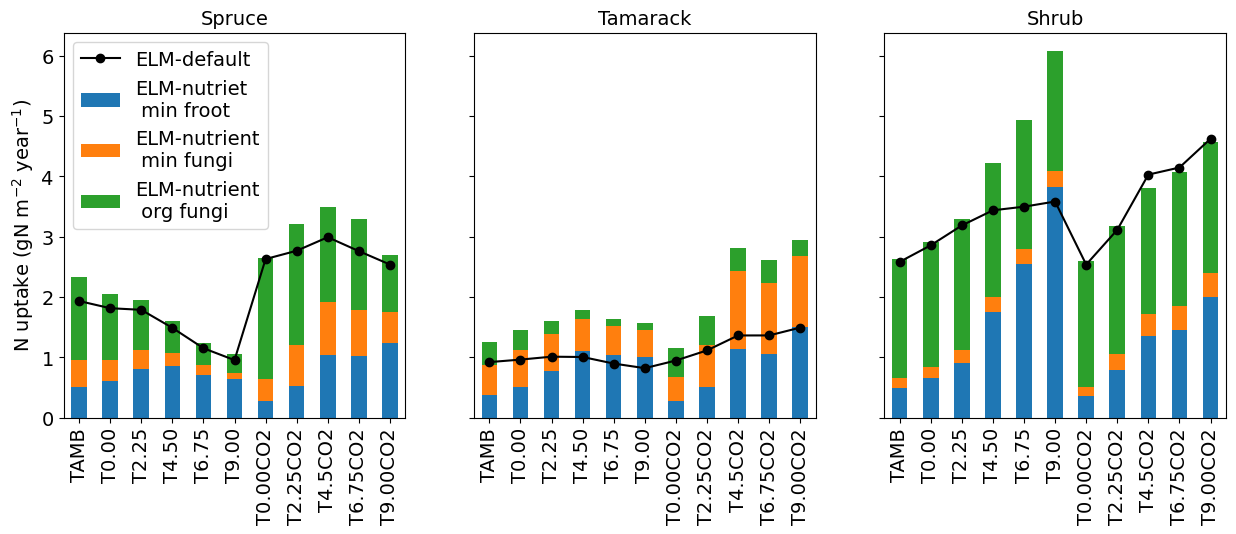

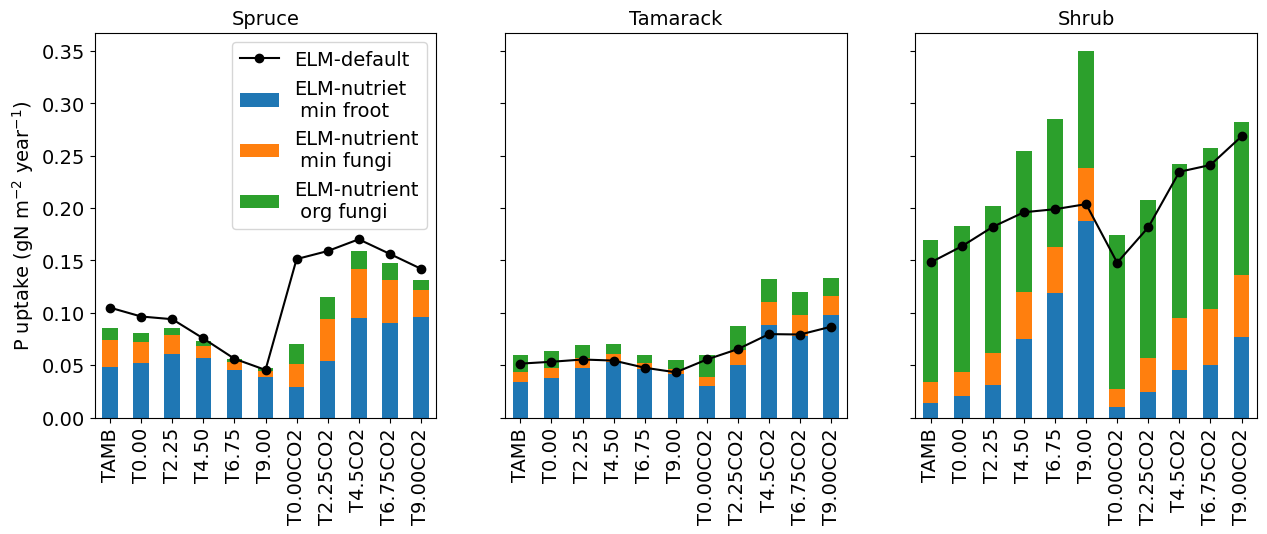

In [44]:
pft_frac = [0.36, 0.14, 0.25, 0.25]

for nu in ['N','P']:
    fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
    for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
        ax = axes.flat[i]

        temp = collection_gs[prefix_default].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] * 86400 * 365 * pft_frac[i]
        ax.plot(range(len(froot_min)), froot_min, '-ko', label = 'ELM-default')

        temp = collection_gs[prefix_uptake].mean(axis = 0).unstack().unstack( \
            ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
        froot_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FROOT_{nu}DEMAND_POT')]
        fungi_min = temp.loc[:, (pft, f'SMIN{nu}_TO_{nu}POOL')] / \
            temp.loc[:, (pft, f'PLANT_{nu}DEMAND_POT')] * \
            temp.loc[:, (pft, f'FUNGI_{nu}DEMAND_POT')]
        fungi_som = temp.loc[:, (pft, f'FUNGI_SOM_TO_{nu}POOL')]
        retemp = pd.concat([froot_min, fungi_min, fungi_som], axis = 1) * 86400 * 365 * pft_frac[i]
        retemp.columns = ['ELM-nutriet\n min froot', 'ELM-nutrient\n min fungi', 'ELM-nutrient\n org fungi']

        #print(nu, pft, name)
        #print(retemp)

        if i == 0:
            retemp.plot(kind='bar', stacked=True, ax = ax)
        else:
            retemp.plot(kind='bar', stacked=True, ax = ax, legend = False)

        if i == 0:
            ax.set_ylabel(f'{nu} uptake ' + '(gN m$^{-2}$ year$^{-1}$)')
            ax.legend()

        ax.set_xticklabels(xticklabels)
        ax.set_xlabel(None)
        ax.set_title(name)

# Soren thinks most of the nutrients from shrub should be from the fungi
# The result is okay. We can discuss it. 

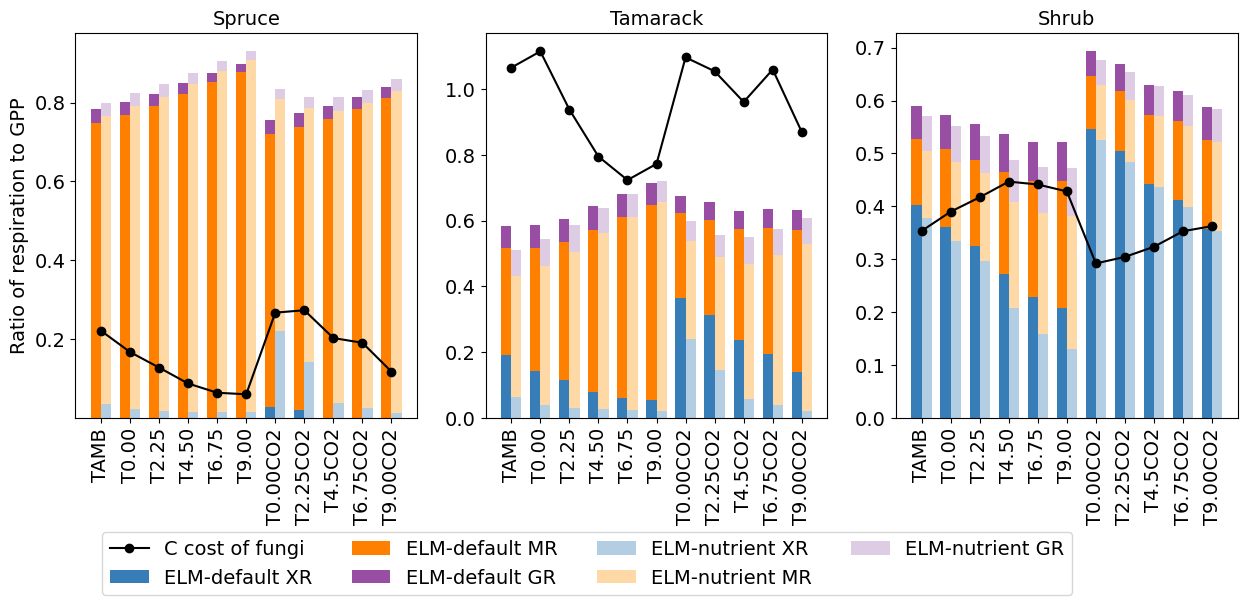

In [45]:
def create_multi_level_stacked_barplot(ax, df):
    """
    Create a stacked bar plot from a DataFrame with two-level columns.
    The first level columns are plotted as separate groups,
    and the second level columns are stacked within each group.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to plot on
    df (pandas.DataFrame): The data to plot, with multi-level columns
    """
    # Get the unique values from the first level of the column index
    top_level = df.columns.get_level_values(0).unique()
    
    # Set up the x locations for the groups
    x = np.arange(len(df.index))
    width = 0.35  # Width of each bar group
    color_list = [
        '#377eb8', '#ff7f00', '#984ea3',
        '#b3cde3', '#fed9a6', '#decbe4'
    ]

    for i, group in enumerate(top_level):
        bottom = np.zeros(len(df.index))
        for j,col in enumerate(df[group].columns):
            ax.bar(x + i*width - width/2, df[group][col], width, bottom=bottom, 
                   label=f'{group} {col}', color=color_list[i*3+j])
            bottom += df[group][col]

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = False)
#fig.subplots_adjust(wspace = 0.05)
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):

    prefix = prefix_default
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    xxr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp = pd.concat([xxr, mr, gr], axis = 1)
    retemp.columns = ['XR', 'MR', 'GR']

    prefix = prefix_uptake
    temp = collection_gs[prefix].mean(axis = 0).unstack().unstack( \
        ).loc[chambers_ordered['amb'] + chambers_ordered['elev'], :]
    cpool_to_fungi = temp.loc[:, (pft, 'CPOOL_TO_FUNGI')] / temp.loc[:, (pft, 'GPP')]
    xxr = temp.loc[:, (pft, 'XR')] / temp.loc[:, (pft, 'GPP')]
    mr = temp.loc[:, (pft, 'MR')] / temp.loc[:, (pft, 'GPP')]
    gr = temp.loc[:, (pft, 'GR')] / temp.loc[:, (pft, 'GPP')]
    retemp2 = pd.concat([xxr, mr, gr], axis = 1)
    retemp2.columns = ['XR', 'MR', 'GR']

    retemp3 = pd.concat([retemp, retemp2], axis = 1, keys = ['ELM-default', 'ELM-nutrient'])

    ax = axes.flat[i]
    create_multi_level_stacked_barplot(ax, retemp3)
    ax.plot(np.arange(temp.shape[0]), 
            cpool_to_fungi, '-o', color = 'k', 
            label = 'C cost of fungi')

    if i == 0:
        ax.set_ylabel('Ratio of respiration to GPP')
        ax.legend(ncol = 4, bbox_to_anchor=(0.05, -0.27), loc='upper left')

    ax.set_xticks(range(len(xticklabels)))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_xlabel(None)
    ax.set_title(name)